# Mock Database MCP Server Implementation

### Short Description
This code demonstrates a simulated Model Context Protocol (MCP) server that provides standardized access to a mock user database. It showcases how AI agents can interact with external data sources through a consistent interface using tool execution patterns.

### Key Libraries Used
Standard Python: No external libraries required, demonstrating core object-oriented programming concepts and dictionary manipulation for data management

### Code Logic and Flow: High-Level Overview
The implementation creates a mock MCP server that simulates database operations through a standardized tool execution interface. The server maintains an in-memory user database and exposes two main operations: retrieving individual user information and fetching all employees within a specific department. The workflow follows a command pattern where the agent calls tools by name with appropriate arguments, and the server routes these requests to the corresponding internal methods while handling errors gracefully.

### Visual Flowchart
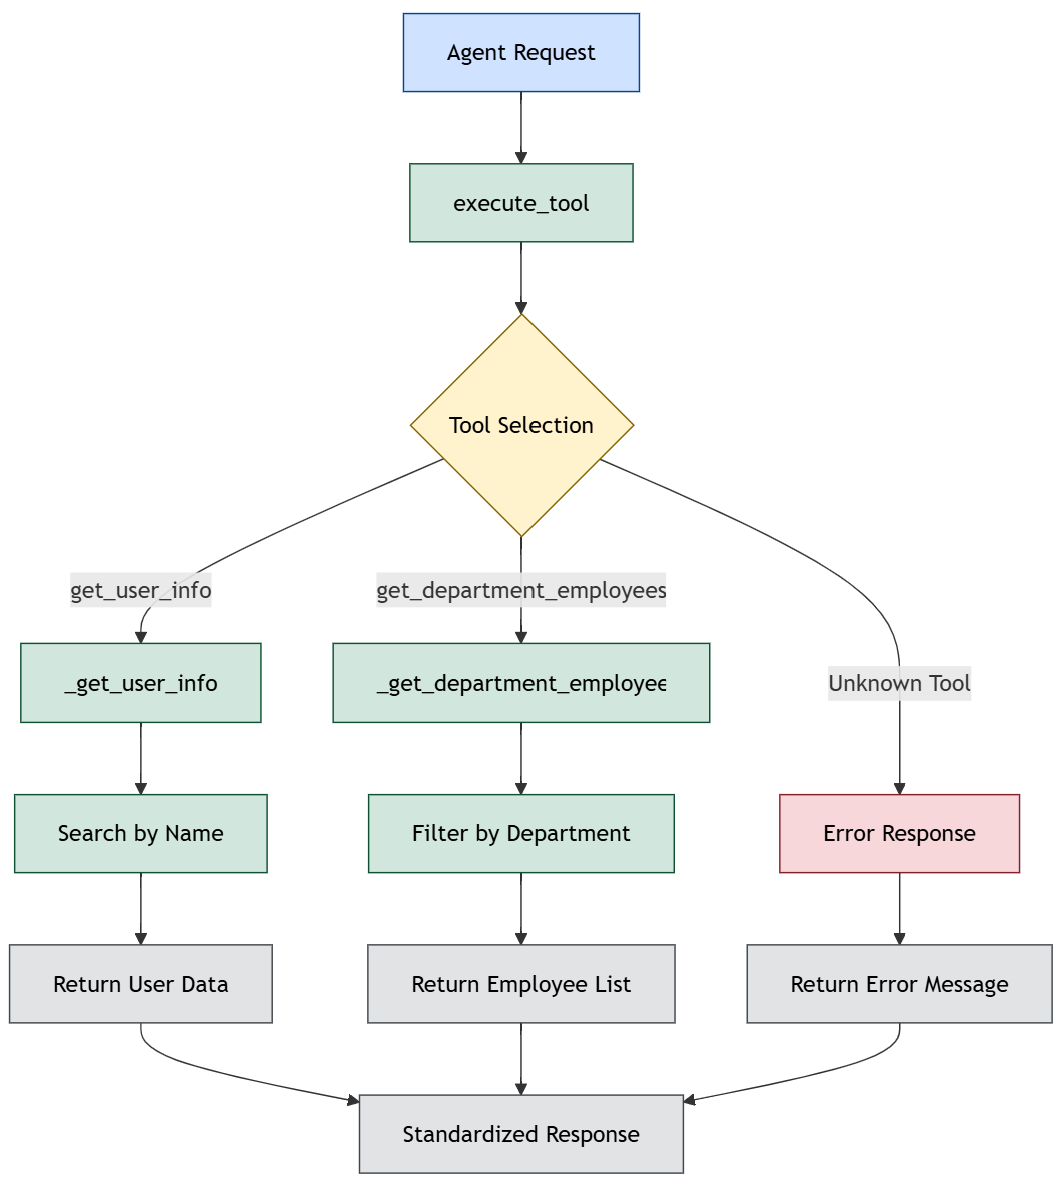

## Step-by-Step Code Breakdown

### Server Initialization
- Creates a mock database with sample user records containing ID, name, and department fields
- Establishes the foundational data structure that the server will operate on

### Tool Execution Interface
- Provides a single entry point (execute_tool) that agents use to interact with the server
- Routes incoming requests to the appropriate internal methods based on the tool name
- Implements error handling for unknown tool requests

### User Information Retrieval
- Processes requests to fetch individual user details by name
- Normalizes input names to ensure case-insensitive matching
- Searches through the user database and returns either the found user record or an error message

### Department Employee Lookup
- Handles requests to find all employees belonging to a specific department
- Filters the user database based on department name with case normalization
- Returns a list of matching employees in a standardized response format

### Connecting to the Lecture
- Standardized Interfaces: Demonstrates how MCP servers provide consistent APIs for AI agents to interact with external systems
- Tool Abstraction: Shows how complex operations are encapsulated behind simple tool calls that agents can reason about
- Error Handling: Illustrates proper error response patterns that help agents understand and recover from failures
- Data Normalization: Highlights the importance of input preprocessing (case normalization) to ensure reliable data matching
- Separation of Concerns: Exemplifies how the execution interface is separated from the actual business logic implementation

In [1]:
# pseudocode_demo.py

class MockDatabaseMCPserver:
    """
    A simulated MCP server that provides a standardized interface to a mock database.
    """
    def __init__(self):
        self.user_db = [
            {"id": 1, "name": "Alice", "department": "Engineering"},
            {"id": 2, "name": "Bob", "department": "Marketing"}
        ]

    def execute_tool(self, tool_name, arguments):
        """The standardized entry point for the agent to use this server's capabilities."""
        if tool_name == "get_user_info":
            return self._get_user_info(arguments)
        elif tool_name == "get_department_employees":
            return self._get_department_employees(arguments)
        else:
            return {"error": f"Tool '{tool_name}' not found."}

    def _get_user_info(self, args):
        """Simulates a tool to get user information by name."""
        user_name = args.get("name", "").title()
        for user in self.user_db:
            if user["name"] == user_name:
                return {"status": "success", "data": user}
        return {"status": "error", "message": f"User '{user_name}' not found."}

    def _get_department_employees(self, args):
        """Simulates a tool to get all employees in a department."""
        department = args.get("department", "").title()
        employees = [user for user in self.user_db if user["department"] == department]
        return {"status": "success", "data": employees}

# Example usage
db_server = MockDatabaseMCPserver()
result = db_server.execute_tool("get_user_info", {"name": "alice"})
print(result)

{'status': 'success', 'data': {'id': 1, 'name': 'Alice', 'department': 'Engineering'}}


# Simulating A2A-Style Agent Delegation

This example shows how a "manager" agent could discover and delegate a task to a specialized "hr" agent using A2A-like principles.

### Short Description
This code demonstrates an agent-to-agent (A2A) ecosystem where specialized AI agents can discover and delegate tasks to each other. It showcases how multiple agents can collaborate by identifying the most suitable agent for a given task and transferring execution responsibilities through a structured delegation protocol.

### Code Logic and Flow: High-Level Overview
The implementation creates a simulated ecosystem where agents with specialized capabilities can be discovered and tasked through a centralized registry system. The workflow begins with task analysis to identify the most appropriate agent based on their declared capabilities. Once a suitable agent is found, the system facilitates task delegation between agents, enabling collaborative problem-solving while maintaining clear responsibility boundaries and status tracking.

### Visual Flowchart
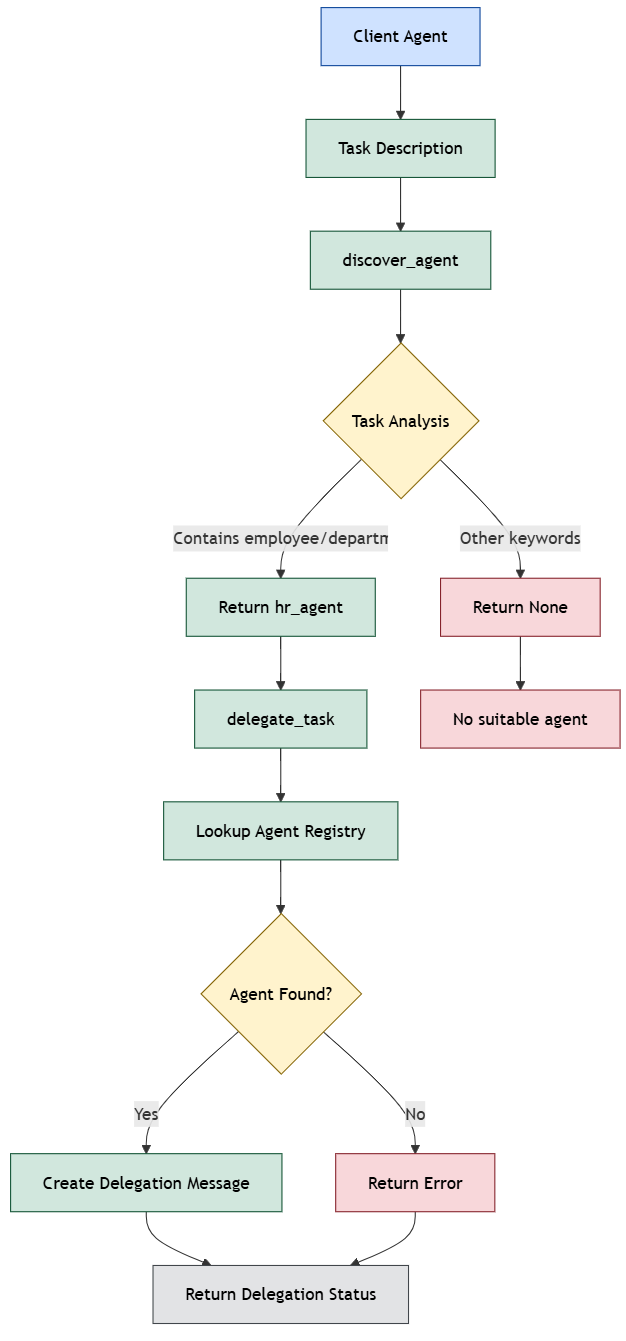

## Step-by-Step Code Breakdown

### Ecosystem Initialization
- Establishes an agent registry containing metadata about available specialized agents
- Defines agent cards with names, descriptions, and capability lists for discovery purposes
- Sets up the foundational directory service for agent lookup and capability matching

### Agent Discovery Process
- Analyzes task descriptions using keyword matching to identify relevant agents
- Implements rule-based routing logic that maps task requirements to agent capabilities
- Returns the most suitable agent identifier or indicates when no appropriate agent is available

### Task Delegation Mechanism
- Handles the formal transfer of task responsibility between client and target agents
- Validates that the target agent exists in the registry before proceeding with delegation
- Generates structured delegation messages that track the task transfer and target agent information

### Response Handling
- Provides clear status updates about delegation success or failure
- Returns informative error messages when agents cannot be found or tasks cannot be delegated
- Maintains communication transparency between collaborating agents

### Connecting to the Lecture
- Agent Specialization: Demonstrates how different agents can focus on specific domains (HR in this case) while remaining accessible to general-         purpose agents
- Capability Discovery: Illustrates the concept of agents advertising their skills through structured metadata that other agents can query
- Task Routing: Shows how complex problems can be decomposed and routed to specialized solvers within a multi-agent system
- Collaborative AI: Exemplifies how multiple AI systems can work together, each contributing their unique expertise to solve broader problems
- Registry Patterns: Connects to service discovery concepts where systems maintain directories of available capabilities and expertise
- Delegation Protocols: Highlights standardized methods for transferring task ownership and responsibility between autonomous agents

In [2]:
# pseudocode_demo_2.py

class SpecializedHREcosystem:
    """
    A simulated ecosystem with agents that can discover and delegate to each other.
    """
    def __init__(self):
        # Simulating an "Agent Card" for the HR agent
        self.agent_registry = {
            'hr_agent': {
                'name': 'HR Information Specialist',
                'description': 'Handles all employee data queries.',
                'capabilities': ['get_user_info', 'get_department_employees']
            }
        }

    def discover_agent(self, task_description):
        """A2A Discovery: Find the best agent for a given task."""
        # Simple rule-based discovery; in reality, this would be more sophisticated.
        if "employee" in task_description or "department" in task_description:
            return 'hr_agent'
        else:
            return None

    def delegate_task(self, client_agent, task, target_agent_id):
        """A2A Execution: Delegate a task to another agent."""
        target_agent = self.agent_registry.get(target_agent_id)
        if target_agent:
            print(f"{client_agent} is delegating the task '{task}' to {target_agent['name']}.")
            # In a real A2A interaction, a structured task object would be sent here.
            return {"status": "delegated", "to_agent": target_agent_id}
        else:
            return {"status": "error", "message": "Agent not found."}

# Example usage
ecosystem = SpecializedHREcosystem()
task = "Find all employees in the Engineering department"
suitable_agent = ecosystem.discover_agent(task)

if suitable_agent:
    result = ecosystem.delegate_task("Manager_Agent", task, suitable_agent)
    print(result)
else:
    print("No suitable agent found for the task.")

Manager_Agent is delegating the task 'Find all employees in the Engineering department' to HR Information Specialist.
{'status': 'delegated', 'to_agent': 'hr_agent'}


### 📈 Looking Ahead: An Interoperable Future

The maturation of MCP and A2A is paving the way for a more collaborative and powerful agentic future. As these standards evolve, we can expect deeper integration with observability frameworks, providing full transparency into multi-agent workflows
. This will be crucial for building trust and scaling agentic AI across the enterprise. The industry is moving towards a reality where developers can focus on building specialized agent capabilities, relying on these open protocols for connectivity, much like how TCP/IP enabled the internet